<a href="https://colab.research.google.com/github/Ropafadzo-Choto1/FUTURE_DS_01/blob/main/Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

df = pd.read_csv("/content/data.csv", encoding="latin1")

# convert date column
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

# create revenue column
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [ ]:
df["Month"] = df["InvoiceDate"].dt.to_period("M")

monthly_revenue = df.groupby("Month")["Revenue"].sum()

monthly_revenue_formatted = monthly_revenue.apply(lambda x: f"${x:,.2f}")

monthly_revenue_formatted

,Revenue
Month,
2010-12,"$748,957.02"
2011-01,"$560,000.26"
2011-02,"$498,062.65"
2011-03,"$683,267.08"
2011-04,"$493,207.12"
2011-05,"$723,333.51"
2011-06,"$691,123.12"
2011-07,"$681,300.11"
2011-08,"$682,680.51"


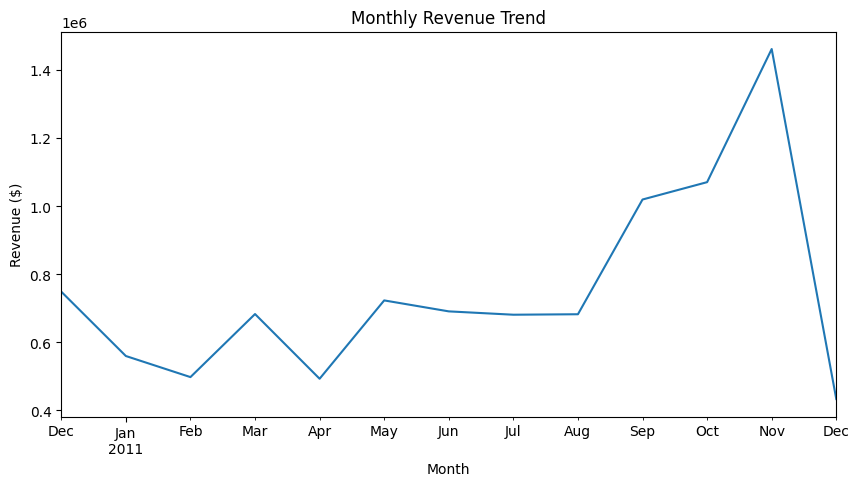

In [ ]:

df["Month"] = df["InvoiceDate"].dt.to_period("M")

monthly_revenue = df.groupby("Month")["Revenue"].sum()

plt.figure(figsize=(10,5))
monthly_revenue.plot()
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue ($)")
plt.show()

**Revenue Trends (Monthly Analysis)**


Revenue dips in January, February, and April, possibly post-holiday season.


Peaks occur in September, October, and November, suggesting strong seasonal demand (likely pre-Christmas).


Highest revenue month: November 2011 ($1,461,756.25)

Lowest revenue month: December 2011 ($433,668.01), possibly due to stockouts or lower sales after peak season.

In [ ]:
top_products = df.groupby("Description")["Revenue"].sum().sort_values(ascending=False)

# Format as dollars
top_products.head(10).apply(lambda x: f"${x:,.2f}")

,Revenue
Description,
DOTCOM POSTAGE,"$206,245.48"
REGENCY CAKESTAND 3 TIER,"$164,762.19"
WHITE HANGING HEART T-LIGHT HOLDER,"$99,668.47"
PARTY BUNTING,"$98,302.98"
JUMBO BAG RED RETROSPOT,"$92,356.03"
RABBIT NIGHT LIGHT,"$66,756.59"
POSTAGE,"$66,230.64"
PAPER CHAIN KIT 50'S CHRISTMAS,"$63,791.94"
ASSORTED COLOUR BIRD ORNAMENT,"$58,959.73"


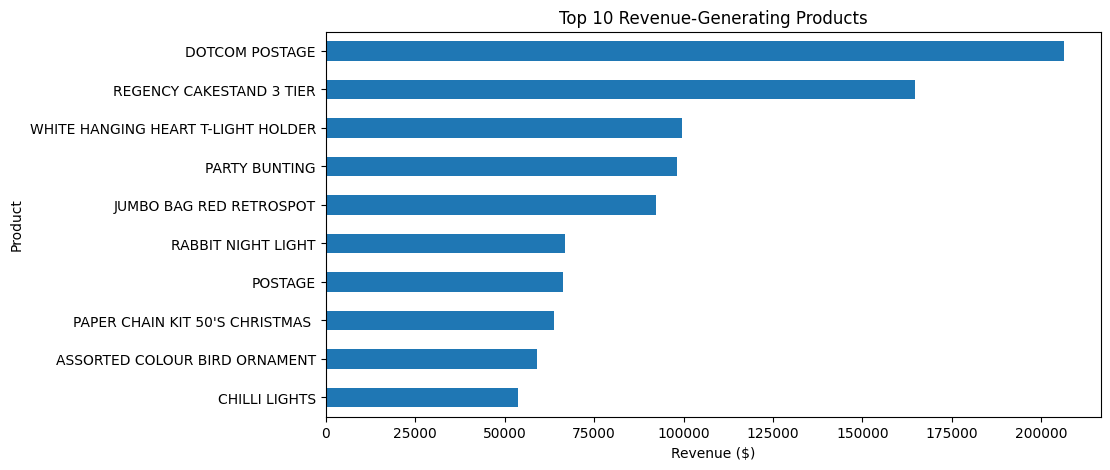

In [ ]:
top_products = df.groupby("Description")["Revenue"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_products.sort_values().plot(kind="barh")  # horizontal bar chart
plt.title("Top 10 Revenue-Generating Products")
plt.xlabel("Revenue ($)")
plt.ylabel("Product")
plt.show()

**Top-Selling Products (Revenue-Based)**


* Postal items (DOTCOM POSTAGE, POSTAGE) are high revenue contributors.

* Seasonal/home decor items (White Hanging Heart T-Light Holder, Party Bunting, Assorted Colour Bird Ornament) perform well.

* Small items with moderate prices but high demand (Regency Cakestand, Jumbo Bag Red Retrospot) drive strong revenue.


**Revenue Trends (Monthly Analysis)**

* Revenue declines are observed in January, February, and April, likely due to post-holiday slowdowns.

* Significant growth begins mid-year, with strong peaks in September, October, and November, indicating seasonal demand.

* Highest revenue month: November 2011 —> $1,461,756.25

* Lowest revenue month: December 2011 —> $433,668.01, possibly due to reduced activity after peak season or inventory shortages.

In [ ]:
top_quantity = df.groupby("Description")["Quantity"].sum().sort_values(ascending=False)

top_quantity.head(10)

,Quantity
Description,
WORLD WAR 2 GLIDERS ASSTD DESIGNS,53847
JUMBO BAG RED RETROSPOT,47363
ASSORTED COLOUR BIRD ORNAMENT,36381
POPCORN HOLDER,36334
PACK OF 72 RETROSPOT CAKE CASES,36039
WHITE HANGING HEART T-LIGHT HOLDER,35317
RABBIT NIGHT LIGHT,30680
MINI PAINT SET VINTAGE,26437
PACK OF 12 LONDON TISSUES,26315


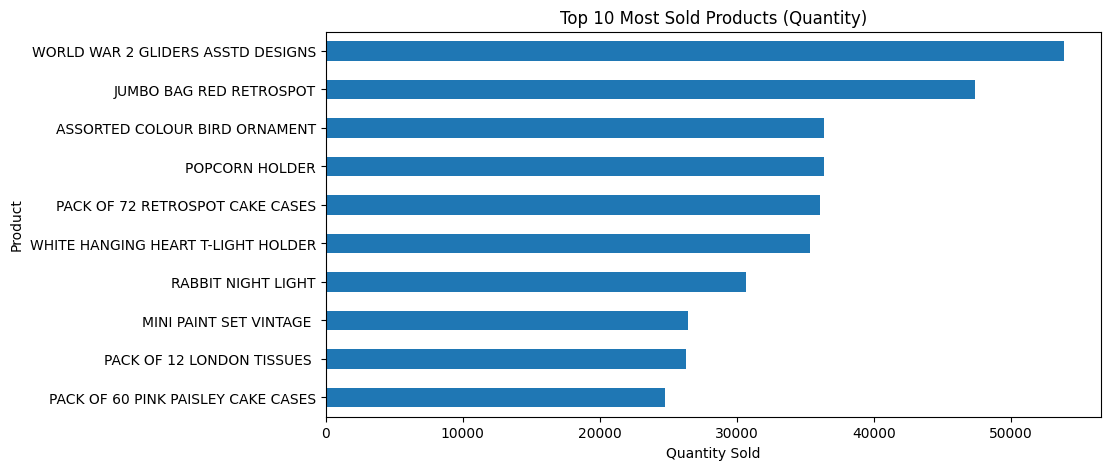

In [ ]:
top_quantity = df.groupby("Description")["Quantity"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_quantity.sort_values().plot(kind="barh")  # horizontal bar chart
plt.title("Top 10 Most Sold Products (Quantity)")
plt.xlabel("Quantity Sold")
plt.ylabel("Product")
plt.show()

**Top-Selling Products (Revenue-Based)**

* DOTCOM POSTAGE and POSTAGE are the highest revenue contributors, highlighting the importance of delivery-related services.

* Decorative and seasonal items such as White Hanging Heart T-Light Holder, Party Bunting, and Assorted Colour Bird Ornament perform strongly.

* Products like Regency Cakestand 3 Tier and Jumbo Bag Red Retrospot generate high revenue due to consistent demand.

**High-Volume Products (Quantity-Based)**

* High sales volume does not always translate into high revenue (e.g., WORLD WAR 2 GLIDERS ASSTD DESIGNS).

* Products like Jumbo Bag Red Retrospot and White Hanging Heart T-Light Holder perform well in both quantity and revenue, making them key products.


In [ ]:
country_sales = df.groupby("Country")["Revenue"].sum().sort_values(ascending=False)
country_sales_formatted = country_sales.apply(lambda x: f"${x:,.2f}")

country_sales_formatted

,Revenue
Country,
United Kingdom,"$8,187,806.36"
Netherlands,"$284,661.54"
EIRE,"$263,276.82"
Germany,"$221,698.21"
France,"$197,403.90"
Australia,"$137,077.27"
Switzerland,"$56,385.35"
Spain,"$54,774.58"
Belgium,"$40,910.96"


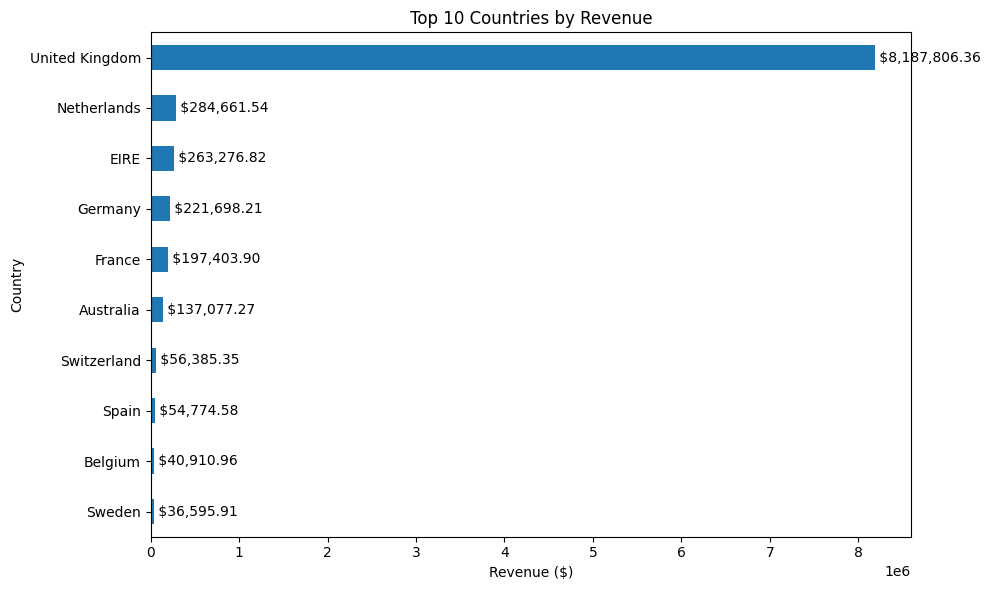

In [ ]:
country_sales = df.groupby("Country")["Revenue"].sum().sort_values(ascending=False).head(10)

# Plot
plt.figure(figsize=(10,6))
ax = country_sales.sort_values().plot(kind="barh")

for i, v in enumerate(country_sales.sort_values()):
    ax.text(v, i, f" ${v:,.2f}", va='center')
plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue ($)")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

**Regional Performance (Revenue by Country)**

* The United Kingdom dominates sales, contributing over 90% of total revenue.

* European markets such as Netherlands, Germany, and France show moderate performance.

* Other countries (Australia, Switzerland, Spain, Belgium, Sweden) contribute smaller shares but present opportunities for expansion.

In [ ]:
top_customers = df.groupby("CustomerID")["Revenue"].sum().sort_values(ascending=False)
top_customers_formatted = top_customers.apply(lambda x: f"${x:,.2f}")

top_customers_formatted

top_customers_formatted.head(10)

,Revenue
CustomerID,
14646.0,"$279,489.02"
18102.0,"$256,438.49"
17450.0,"$187,482.17"
14911.0,"$132,572.62"
12415.0,"$123,725.45"
14156.0,"$113,384.14"
17511.0,"$88,125.38"
16684.0,"$65,892.08"
13694.0,"$62,653.10"


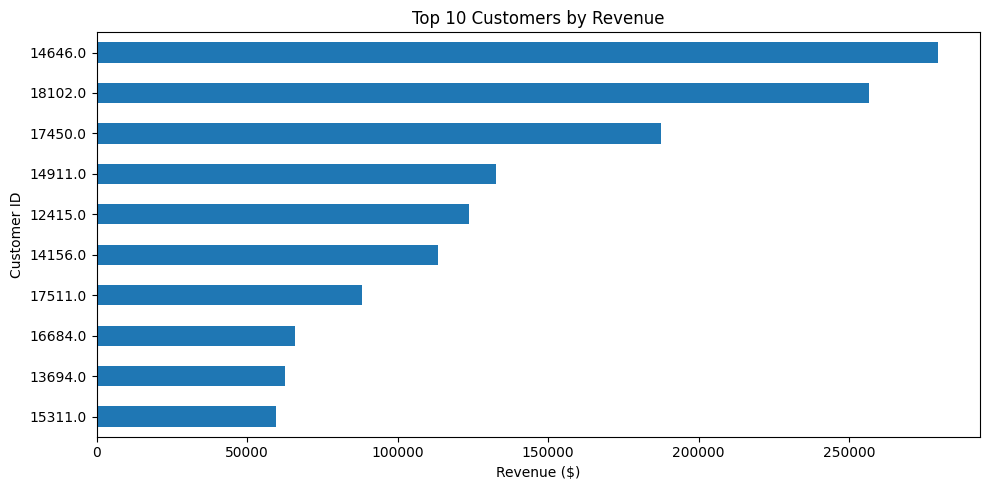

In [ ]:
top_customers = df.groupby("CustomerID")["Revenue"].sum().sort_values(ascending=False).head(10)

# Plot (horizontal bar for better readability)
plt.figure(figsize=(10,5))
top_customers.sort_values().plot(kind="barh")

# Labels and title
plt.title("Top 10 Customers by Revenue")
plt.xlabel("Revenue ($)")
plt.ylabel("Customer ID")

plt.tight_layout()
plt.show()

**Top Customers (Revenue Contribution)**

* The top 3 customers contribute over 30% of total revenue, indicating reliance on a few high-value clients.

* Maintaining strong relationships with these customers is critical for sustained revenue.

* Mid-tier customers present an opportunity for growth through targeted marketing and upselling strategies.

**Overall Insights & Recommendations**


*   Leverage seasonality: Increase inventory and marketing efforts ahead of peak months (September–November).
*   Stabilize low periods: Introduce promotions and discounts during early-year slow months.


*  Product strategy: Focus on items that perform well in both revenue and volume.

*  Market expansion: Strengthen dominance in the UK while investing in growth across European and international markets.

* Customer strategy: Implement loyalty programs for top customers and develop strategies to grow mid-level clients.